# Abbildungen: Prototyp vs. MQA (Kapitel 5.8)

Erzeugt die Abbildungen für den Abschnitt "Ergebnisse: Prototyp und MQA im Vergleich" — Kernstichprobe (n=50) und Extremfälle (n=20). Stilistisch an die Notebooks 15/16 angelehnt (dieselbe Blau-Palette, Spines, Grid), ergänzt um eine neutrale Graufarbe für die MQA-Baseline.

**Datenkorrektur gegenüber Notebook 11:** Der zuletzt dort gecachte Vergleich (`comparison_sample_2026-06-25_09-57_20260720_103043`) lief mit `state_evaluation_weighted.yaml` und dem Sonnet-4.6-Run — beides vor der in Kapitel 5.6 getroffenen finalen Entscheidung (GPT-5.5, `state_evaluation_final.yaml`). Dieses Notebook baut den Prototyp-Indikator-Join deshalb neu aus dem finalen GPT-5.5-Lauf auf; die MQA-Seite der Kernstichprobe wird unverändert übernommen (deterministisch, hängt nicht vom Prototyp-Modell ab — nur die HTTP-Probe-Ergebnisse zählen, und die RDF-Dateien sind identisch). Für die Extremfälle gibt es noch keinen Vergleich; die MQA-Metriken werden hier erstmals berechnet (Live-HTTP-Probe, ca. 2 Minuten für 20 Dateien).

In [1]:
# ---------------------------------------------------------------------------
# EINGABE
# ---------------------------------------------------------------------------
# Kernstichprobe (n=50): finaler GPT-5.5-Lauf (identisch zu Notebook 16).
KERN_MODEL_RUN = "outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5"
KERN_SAMPLE_DIR = "data/sample_2026-06-25_09-57"
KERN_GT = "data/sample_2026-06-25_09-57/ground_truth_template_slim.csv"
# MQA-Metriken der Kernstichprobe sind vom Prototyp-Modell unabhaengig (rein
# deterministisch/Probe-basiert) -- Wiederverwendung aus dem letzten Lauf statt
# erneuter Live-HTTP-Probes.
KERN_MQA_CACHE = "outputs/mqa_comparison/comparison_sample_2026-06-25_09-57_20260720_103043/mqa_metrics.csv"
KERN_OUT = "outputs/mqa_comparison/comparison_sample_2026-06-25_09-57_gpt5-5_final"

# Extremfaelle (n=20): finaler, blind bewerteter Stand.
EXTREM_MODEL_RUN = "outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL"
EXTREM_SAMPLE_DIR = "data/extreme_cases_05"
EXTREM_GT = "data/extreme_cases_05/ground_truth_template_slim.csv"
EXTREM_OUT = "outputs/mqa_comparison/comparison_extreme_cases_05_gpt5-5_final"

# True: MQA-Metriken der Extremfaelle live neu proben (HTTP-Requests, ~2 Min.).
# False: gecachte mqa_metrics.csv aus EXTREM_OUT wiederverwenden, falls vorhanden.
EXTREM_RECOMPUTE_MQA = False

AUSGABE_ORDNER = "thesis/images"

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

%matplotlib inline

REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT / "src"))

from evaluation import indicator_join as ij  # noqa: E402

out_dir = REPO_ROOT / AUSGABE_ORDNER
out_dir.mkdir(parents=True, exist_ok=True)


def spearman(x, y):
    """Spearman rho via Rang-Pearson (keine scipy-Abhaengigkeit)."""
    rx = np.argsort(np.argsort(x)).astype(float)
    ry = np.argsort(np.argsort(y)).astype(float)
    return float(np.corrcoef(rx, ry)[0, 1])


def scatter_and_triangulate(out_dir, gt_csv, model_col="model_score_norm"):
    """MQA-/Prototyp-Gesamtscore je Datei + Rangkorrelation beider Systeme
    gegen jedes GT-Ziel (gesamt, ohne Aussagekraft, je Dimension)."""
    out_dir = Path(out_dir)
    mqa_raw = pd.read_csv(out_dir / "mqa_metrics.csv")
    mqa_per_file = (
        mqa_raw.groupby("file")
        .apply(lambda g: pd.Series({
            "mqa_score_norm": g["mqa_points"].sum() / g["mqa_max"].sum()
            if g["mqa_max"].sum() > 0 else float("nan")
        }))
        .reset_index()
    )
    model_raw = pd.read_csv(out_dir / "model_indicators.csv")
    model_per_file = (
        model_raw.groupby("file")["model_overall"].first()
        .reset_index().rename(columns={"model_overall": "model_score_norm"})
    )
    scatter_df = mqa_per_file.merge(model_per_file, on="file")
    scatter_df.to_csv(out_dir / "scatter_df.csv", index=False)

    gt_df = pd.read_csv(gt_csv)
    GT_DIMS = ["findability", "accessibility", "reusability", "expressiveness"]
    gt_df["gt_overall"] = gt_df[[f"gt_{d}" for d in GT_DIMS]].mean(axis=1)
    gt_df["gt_overall_ohne_expr"] = gt_df[[f"gt_{d}" for d in GT_DIMS[:3]]].mean(axis=1)
    tri = gt_df.merge(scatter_df[["file", "model_score_norm", "mqa_score_norm"]], on="file")

    targets = (
        [("gesamt (4 Dim.)", "gt_overall"), ("ohne Expressiveness (3 Dim.)", "gt_overall_ohne_expr")]
        + [(d, f"gt_{d}") for d in GT_DIMS]
    )
    rows = [{
        "ziel": lbl,
        "prot_rho": spearman(tri["model_score_norm"].to_numpy(), tri[col].to_numpy(dtype=float)),
        "mqa_rho": spearman(tri["mqa_score_norm"].to_numpy(), tri[col].to_numpy(dtype=float)),
    } for lbl, col in targets]
    tri_df = pd.DataFrame(rows)
    tri_df["delta"] = tri_df["prot_rho"] - tri_df["mqa_rho"]
    tri_df.to_csv(out_dir / "gt_triangulation.csv", index=False)
    return scatter_df, tri_df


DIM_DE = {"gesamt (4 Dim.)": "Gesamt (4 Dim.)",
          "ohne Expressiveness (3 Dim.)": "Ohne Aussagekraft (3 Dim.)",
          "findability": "Auffindbarkeit", "accessibility": "Zugänglichkeit",
          "reusability": "Wiederverwendbarkeit", "expressiveness": "Aussagekraft"}

## 1. Kernstichprobe: Indikator-Join mit dem finalen GPT-5.5-Lauf neu aufbauen

In [3]:
kern_out = (REPO_ROOT / KERN_OUT)
kern_out.mkdir(parents=True, exist_ok=True)

kern_model_long = ij.load_model_indicators_from_run(REPO_ROOT / KERN_MODEL_RUN)
kern_model_long.to_csv(kern_out / "model_indicators.csv", index=False)

kern_mqa_long = pd.read_csv(REPO_ROOT / KERN_MQA_CACHE)
kern_mqa_long.to_csv(kern_out / "mqa_metrics.csv", index=False)

kern_join = ij.build_join(kern_model_long, kern_mqa_long)
kern_join.to_csv(kern_out / "indicator_join.csv", index=False)
kern_summ = ij.summarise(kern_join)

print("Kernstichprobe — Klassenzählung:", kern_summ["class_counts"])
print("[A] Konvergenz:", kern_summ["class_a"])

loaded model indicators from existing run: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5 (50 files)
Kernstichprobe — Klassenzählung: {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz: {'n': 450, 'agreement': 0.96, 'both_pass': 298, 'both_fail': 134, 'mqa_pass_model_fail': 17, 'model_pass_mqa_fail': 1}


## 2. Extremfälle: Indikator-Join neu berechnen (MQA erstmals auf `extreme_cases_05`)

In [4]:
extrem_out = (REPO_ROOT / EXTREM_OUT)
extrem_out.mkdir(parents=True, exist_ok=True)

extrem_model_long = ij.load_model_indicators_from_run(REPO_ROOT / EXTREM_MODEL_RUN)
extrem_model_long.to_csv(extrem_out / "model_indicators.csv", index=False)

extrem_mqa_cache = extrem_out / "mqa_metrics.csv"
if extrem_mqa_cache.exists() and not EXTREM_RECOMPUTE_MQA:
    extrem_mqa_long = pd.read_csv(extrem_mqa_cache)
    print(f"cache: {extrem_mqa_cache}")
else:
    extrem_mqa_long = ij.run_mqa_metrics(REPO_ROOT / EXTREM_SAMPLE_DIR, probe=True)
    extrem_mqa_long.to_csv(extrem_mqa_cache, index=False)

extrem_join = ij.build_join(extrem_model_long, extrem_mqa_long)
extrem_join.to_csv(extrem_out / "indicator_join.csv", index=False)
extrem_summ = ij.summarise(extrem_join)

print("Extremfälle — Klassenzählung:", extrem_summ["class_counts"])
print("[A] Konvergenz:", extrem_summ["class_a"])

loaded model indicators from existing run: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL (20 files)
cache: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/mqa_comparison/comparison_extreme_cases_05_gpt5-5_final/mqa_metrics.csv
Extremfälle — Klassenzählung: {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz: {'n': 180, 'agreement': 0.9555555555555556, 'both_pass': 116, 'both_fail': 56, 'mqa_pass_model_fail': 8, 'model_pass_mqa_fail': 0}


In [5]:
kern_scatter, kern_tri = scatter_and_triangulate(kern_out, REPO_ROOT / KERN_GT)
extrem_scatter, extrem_tri = scatter_and_triangulate(extrem_out, REPO_ROOT / EXTREM_GT)

print("Kernstichprobe Triangulation (H3):")
print(kern_tri.round(3).to_string(index=False))
print()
print("Extremfälle Triangulation (H3):")
print(extrem_tri.round(3).to_string(index=False))

Kernstichprobe Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.779    0.740  0.038
ohne Expressiveness (3 Dim.)     0.695    0.671  0.024
                 findability     0.134    0.252 -0.119
               accessibility     0.591    0.569  0.022
                 reusability     0.457    0.426  0.031
              expressiveness     0.682    0.611  0.071

Extremfälle Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.845    0.699  0.146
ohne Expressiveness (3 Dim.)     0.856    0.710  0.146
                 findability     0.755    0.671  0.084
               accessibility     0.901    0.806  0.095
                 reusability     0.841    0.729  0.111
              expressiveness     0.651    0.529  0.122


## 3. Stil (identisch zu Notebook 15/16, plus MQA-Farbe)

In [6]:
HAUPT = "#2a78d6"        # Prototyp (= FARBEN["GPT-5.5"] aus Notebook 15)
CEILING = "#aec6e8"       # helle Toenung von HAUPT
MQA = "#9aa3ad"           # neutral/grau: etablierte Baseline, bewusst nicht "unsere" Farbe
DISAGREE = "#c9503f"
VERDICT = {"gut": "#2f8f46", "mittel": "#d9a441", "schlecht": "#c9503f"}
TEXT, TEXT_SEK, GRID = "#0b0b0b", "#52514e", "#d8d7d2"


def stil(ax):
    for r in ("top", "right"):
        ax.spines[r].set_visible(False)
    for r in ("left", "bottom"):
        ax.spines[r].set_color(GRID)
    ax.tick_params(colors=TEXT_SEK, labelsize=9)


def speichern(fig, name):
    for endung in ("png", "pdf"):
        p = out_dir / f"{name}.{endung}"
        fig.savefig(p, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"geschrieben: {p.relative_to(REPO_ROOT)}")

## Abbildung 1/7: [A] Konvergenz-Konfusionsmatrix (Kernstichprobe)

Blau = Übereinstimmung (beide PASS / beide FAIL), Rot = Divergenz. Alpha kodiert die Zellhäufigkeit relativ zur größten Zelle.

geschrieben: thesis/images/mqa_konvergenz_matrix.png
geschrieben: thesis/images/mqa_konvergenz_matrix.pdf


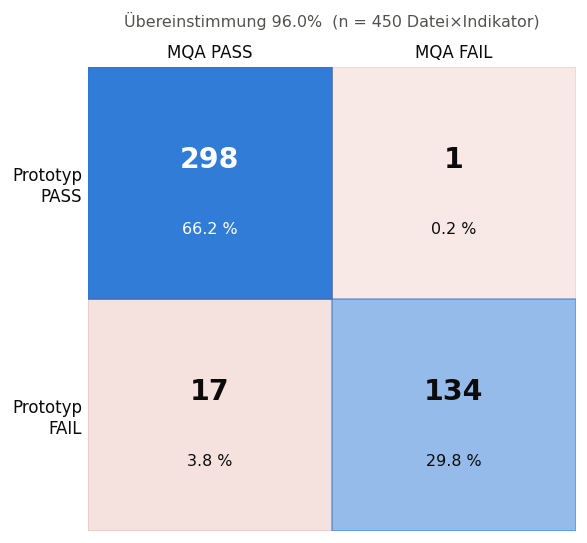

In [7]:
def fig_konvergenz(summ, name):
    a = summ["class_a"]
    mat = np.array([[a["both_pass"], a["model_pass_mqa_fail"]],
                     [a["mqa_pass_model_fail"], a["both_fail"]]], dtype=float)
    total = mat.sum()
    agree_mask = np.array([[True, False], [False, True]])

    fig, ax = plt.subplots(figsize=(5.0, 4.6))
    for i in range(2):
        for j in range(2):
            base = HAUPT if agree_mask[i, j] else DISAGREE
            norm = mat[i, j] / mat.max()
            alpha = 0.12 + 0.85 * norm
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                        color=(*mcolors.to_rgb(base), alpha), zorder=1))
            val = int(mat[i, j])
            farbe = "white" if alpha > 0.55 else TEXT
            ax.text(j, i - 0.10, str(val), ha="center", va="center", fontsize=17,
                    fontweight="bold", color=farbe, zorder=3)
            ax.text(j, i + 0.20, f"{100 * val / total:.1f} %", ha="center", va="center",
                    fontsize=9.5, color=farbe, zorder=3)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["MQA PASS", "MQA FAIL"], fontsize=10, color=TEXT)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Prototyp\nPASS", "Prototyp\nFAIL"], fontsize=10, color=TEXT)
    ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
    for r in ax.spines.values():
        r.set_visible(False)
    ax.tick_params(length=0)
    ax.set_title(f"Übereinstimmung {a['agreement']:.1%}  (n = {a['n']} Datei×Indikator)",
                 fontsize=9.5, color=TEXT_SEK, pad=10)
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_konvergenz(kern_summ, "mqa_konvergenz_matrix")

## Abbildung 2/7: [B] Überschätzungsrate je Indikator (Kernstichprobe)

Anteil der Fälle, in denen MQA PASS vergibt (Vorhandensein genügt), der Prototyp aber FAIL (Gültigkeit/Kongruenz fehlt) — der direkte Beleg für H2.

geschrieben: thesis/images/mqa_ueberschaetzung.png
geschrieben: thesis/images/mqa_ueberschaetzung.pdf


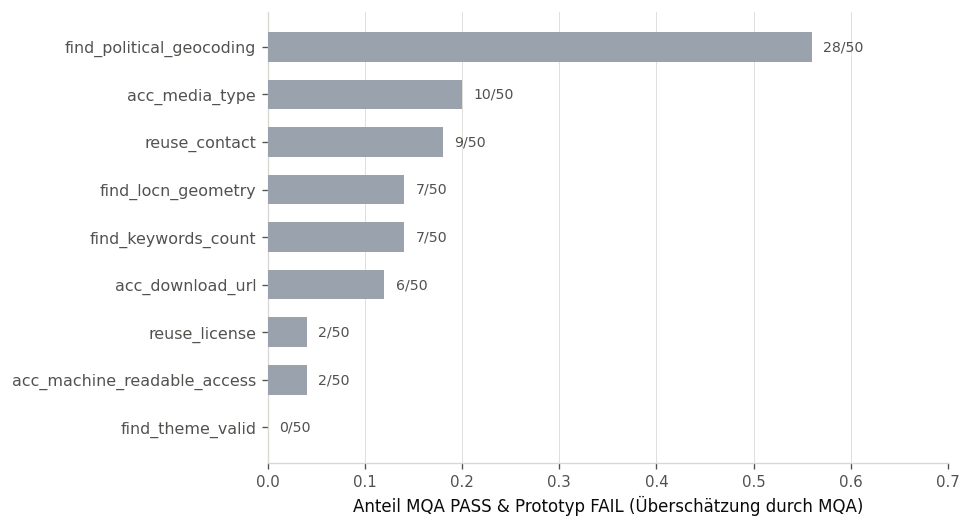

In [8]:
def fig_ueberschaetzung(summ, name):
    b = summ["class_b"].sort_values("overestimation_rate", ascending=True)
    fig, ax = plt.subplots(figsize=(8.2, max(2.6, len(b) * 0.5)))
    farben = [MQA if r > 0 else CEILING for r in b["overestimation_rate"]]
    bars = ax.barh(b["indicator"], b["overestimation_rate"], color=farben, zorder=3, height=0.62)
    for bar, (_, row) in zip(bars, b.iterrows()):
        ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
                f"{int(row['mqa_pass_model_fail'])}/{int(row['n'])}",
                va="center", fontsize=8.5, color=TEXT_SEK)
    ax.set_xlabel("Anteil MQA PASS & Prototyp FAIL (Überschätzung durch MQA)", fontsize=10, color=TEXT)
    ax.set_xlim(0, max(0.65, b["overestimation_rate"].max() * 1.25))
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.tick_params(axis="y", labelsize=9.5)
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_ueberschaetzung(kern_summ, "mqa_ueberschaetzung")

## Abbildung 3/7: [C] Prototyp-Score-Verteilung je C-Indikator (Kernstichprobe)

Für diese Indikatoren hat die MQA keine Metrik — die gestrichelte Linie bei 0,5 macht sichtbar, dass der Prototyp hier tatsächlich variiert, statt konstruktiv flach zu bleiben.

geschrieben: thesis/images/mqa_blindheit_boxplot.png
geschrieben: thesis/images/mqa_blindheit_boxplot.pdf


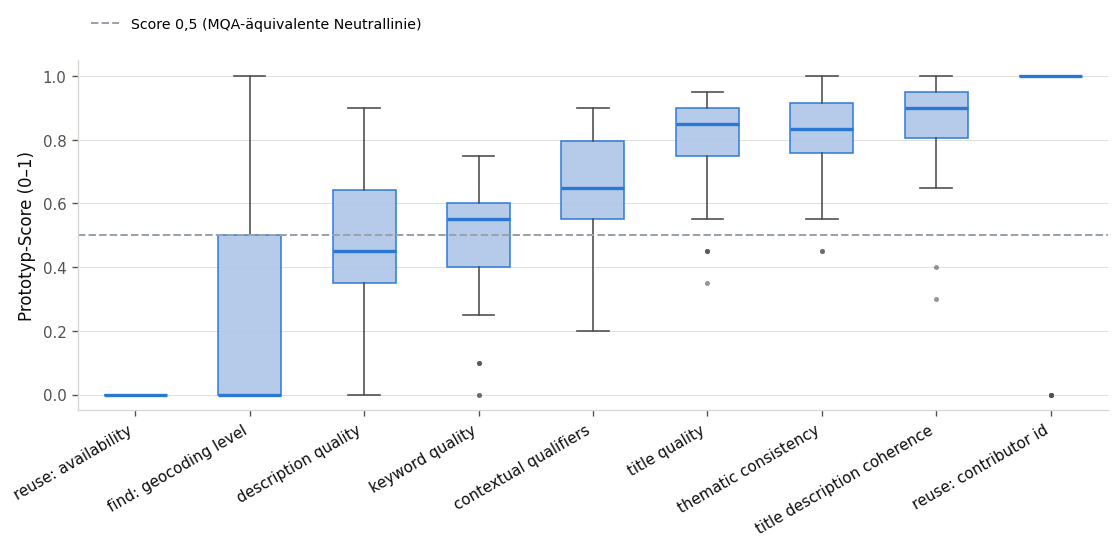

In [9]:
c_inds = kern_summ["class_c"]["indicator"].tolist()
c_data = [kern_join.loc[(kern_join["indicator"] == ind) & kern_join["model_score"].notna(), "model_score"]
          .astype(float).tolist() for ind in c_inds]
c_labels = [i.replace("expr_", "").replace("reuse_", "reuse: ").replace("find_", "find: ").replace("_", " ")
            for i in c_inds]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bp = ax.boxplot(c_data, tick_labels=c_labels, patch_artist=True, widths=0.55,
                medianprops=dict(color=HAUPT, lw=2),
                whiskerprops=dict(color=TEXT_SEK), capprops=dict(color=TEXT_SEK),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=TEXT_SEK,
                                markeredgecolor="none", alpha=0.6))
for box in bp["boxes"]:
    box.set_facecolor(CEILING)
    box.set_edgecolor(HAUPT)
    box.set_alpha(0.9)
ax.axhline(0.5, color=MQA, lw=1.2, ls="--", zorder=2, label="Score 0,5 (MQA-äquivalente Neutrallinie)")
ax.set_ylabel("Prototyp-Score (0–1)", fontsize=10, color=TEXT)
ax.set_ylim(-0.05, 1.05)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
plt.setp(ax.get_xticklabels(), fontsize=9, color=TEXT, rotation=30, ha="right")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(0.0, 1.16))
fig.tight_layout()
speichern(fig, "mqa_blindheit_boxplot")
plt.show()

## Abbildung 4/7: Gesamt-Scatter Prototyp vs. MQA (Kernstichprobe)

geschrieben: thesis/images/mqa_scatter_gesamt.png
geschrieben: thesis/images/mqa_scatter_gesamt.pdf


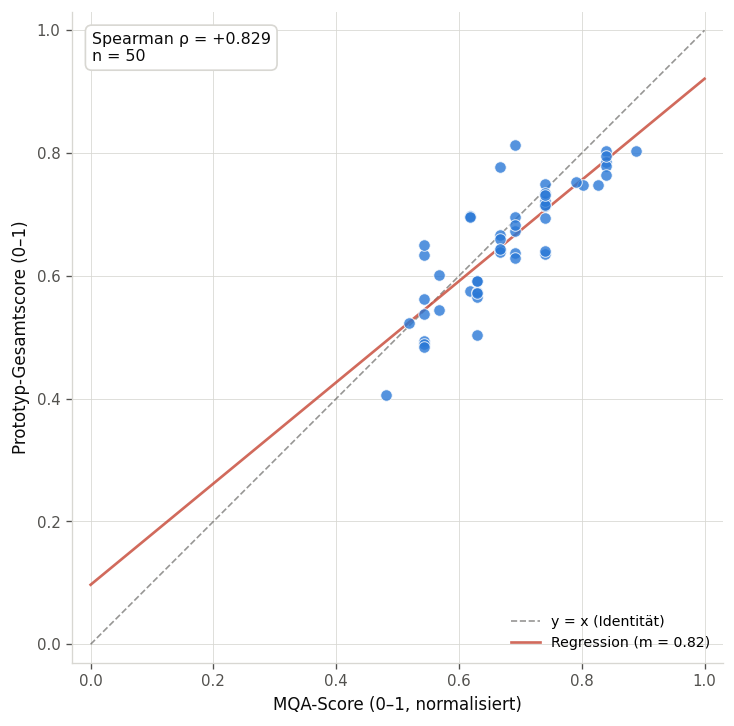

In [10]:
def fig_scatter(scatter_df, name):
    x = scatter_df["mqa_score_norm"].to_numpy(float)
    y = scatter_df["model_score_norm"].to_numpy(float)
    valid = ~(np.isnan(x) | np.isnan(y))
    xv, yv = x[valid], y[valid]
    sp = spearman(xv, yv)
    m, b_coef = np.polyfit(xv, yv, 1)
    x_line = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.plot([0, 1], [0, 1], linestyle="--", color=TEXT_SEK, lw=1, alpha=0.6, zorder=2,
            label="y = x (Identität)")
    ax.plot(x_line, m * x_line + b_coef, color=VERDICT["schlecht"], lw=1.6, alpha=0.85,
            zorder=2, label=f"Regression (m = {m:.2f})")
    ax.scatter(xv, yv, s=48, color=HAUPT, alpha=0.8, edgecolor="white", linewidth=0.6, zorder=3)
    ax.text(0.03, 0.97, f"Spearman ρ = {sp:+.3f}\nn = {len(xv)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9.5, color=TEXT,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GRID))
    ax.set_xlabel("MQA-Score (0–1, normalisiert)", fontsize=10, color=TEXT)
    ax.set_ylabel("Prototyp-Gesamtscore (0–1)", fontsize=10, color=TEXT)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")
    ax.set_axisbelow(True)
    ax.grid(linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_scatter(kern_scatter, "mqa_scatter_gesamt")

## Abbildung 5–6/7: Triangulation (H3) — Prototyp-ρ vs. MQA-ρ gegen die Ground Truth

Je einmal für die Kernstichprobe und die Extremfälle. Das ist die Synthese-Abbildung des Kapitels: Sie beantwortet nicht nur, *dass* Prototyp und MQA unterschiedlich messen, sondern *wer näher am menschlichen Urteil liegt*.

geschrieben: thesis/images/mqa_triangulation_kernstichprobe.png
geschrieben: thesis/images/mqa_triangulation_kernstichprobe.pdf


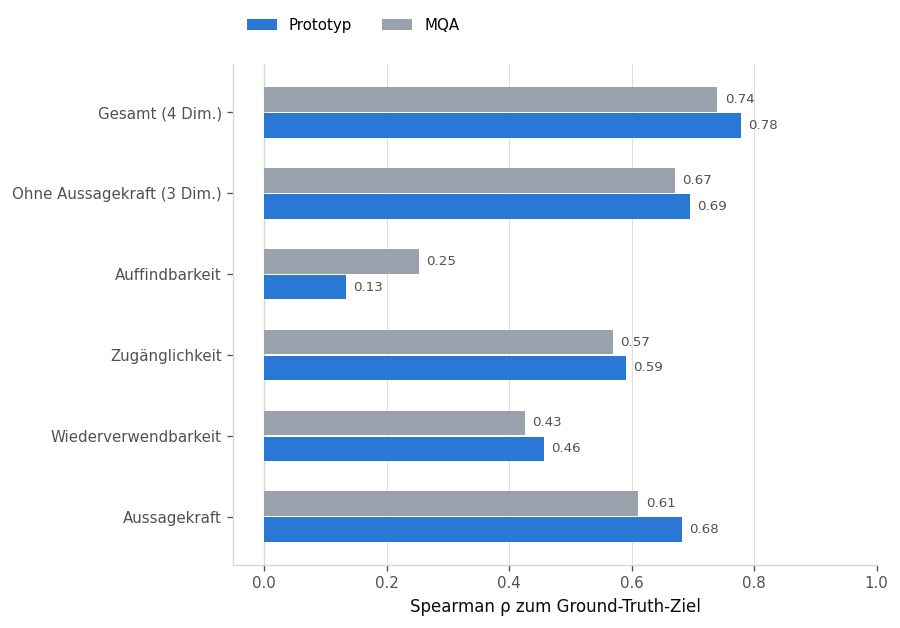

In [11]:
def fig_triangulation(tri, name):
    labels = [DIM_DE[z] for z in tri["ziel"]]
    y = np.arange(len(tri))
    hoehe = 0.32

    fig, ax = plt.subplots(figsize=(7.6, 0.72 * len(tri) + 1.0))
    b1 = ax.barh(y + hoehe / 2, tri["prot_rho"], hoehe * 0.95, color=HAUPT, label="Prototyp", zorder=3)
    b2 = ax.barh(y - hoehe / 2, tri["mqa_rho"], hoehe * 0.95, color=MQA, label="MQA", zorder=3)
    for bars in (b1, b2):
        for bar in bars:
            w = bar.get_width()
            ax.text(w + (0.012 if w >= 0 else -0.012), bar.get_y() + bar.get_height() / 2,
                    f"{w:.2f}", va="center", ha="left" if w >= 0 else "right",
                    fontsize=8, color=TEXT_SEK)
    ax.axvline(0, color=GRID, lw=0.8, zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9.5, color=TEXT)
    ax.invert_yaxis()
    ax.set_xlabel("Spearman ρ zum Ground-Truth-Ziel", fontsize=10, color=TEXT)
    ax.set_xlim(min(-0.05, tri[["prot_rho", "mqa_rho"]].min().min() - 0.08), 1.0)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.12))
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_triangulation(kern_tri, "mqa_triangulation_kernstichprobe")

In [12]:
fig_triangulation(extrem_tri, "mqa_triangulation_extremfaelle")

geschrieben: thesis/images/mqa_triangulation_extremfaelle.png
geschrieben: thesis/images/mqa_triangulation_extremfaelle.pdf


## Abbildung 7/7: Trennschärfe MQA vs. Prototyp auf den Extremfällen

Beide Systeme nebeneinander auf denselben konstruierten Gruppen (`good_*` vs. `bad_*`) — zeigt, ob die MQA-Baseline dieselbe Trennschärfe erreicht wie der Prototyp oder ob sie (wie die Kalibrierungs-Differenz in Abbildung 4 nahelegt) systematisch großzügiger bewertet.

geschrieben: thesis/images/mqa_extremfaelle_trennschaerfe.png
geschrieben: thesis/images/mqa_extremfaelle_trennschaerfe.pdf


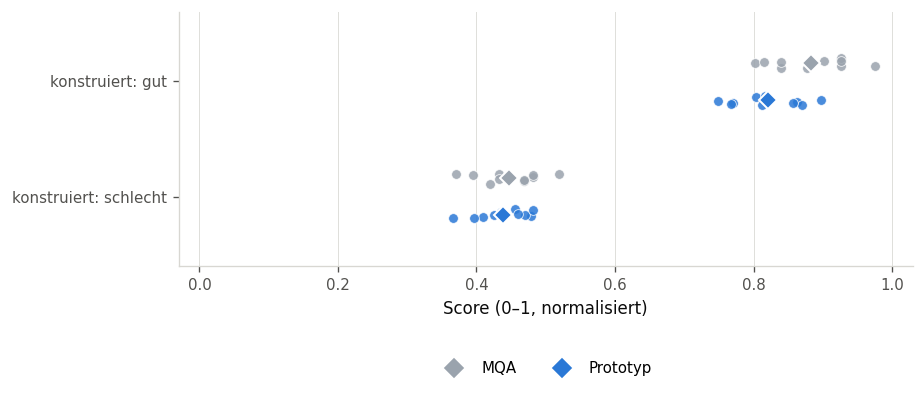

In [13]:
extrem_scatter["gruppe"] = np.where(
    extrem_scatter["file"].str.startswith("good_"), "konstruiert: gut", "konstruiert: schlecht"
)
gruppen = ["konstruiert: schlecht", "konstruiert: gut"]
systeme = [("mqa_score_norm", "MQA", MQA), ("model_score_norm", "Prototyp", HAUPT)]

fig, ax = plt.subplots(figsize=(7.8, 3.6))
rng = np.random.default_rng(7)
y_offsets = {"MQA": 0.16, "Prototyp": -0.16}
for i, gname in enumerate(gruppen):
    sub = extrem_scatter[extrem_scatter["gruppe"] == gname]
    for col, sys_label, farbe in systeme:
        y0 = i + y_offsets[sys_label]
        jitter = rng.uniform(-0.05, 0.05, size=len(sub))
        ax.scatter(sub[col], np.full(len(sub), y0) + jitter, s=34, color=farbe, alpha=0.85,
                   edgecolor="white", linewidth=0.5, zorder=3)
        mittel = sub[col].mean()
        ax.plot(mittel, y0, "D", markersize=8, color=farbe, markeredgecolor="white",
                markeredgewidth=1.2, zorder=4)

ax.set_yticks(range(len(gruppen)))
ax.set_yticklabels(gruppen, fontsize=10, color=TEXT)
ax.set_xlabel("Score (0–1, normalisiert)", fontsize=10, color=TEXT)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.6, len(gruppen) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
handles = [Line2D([], [], marker="D", linestyle="none", color=farbe, markersize=8, label=lbl)
           for _, lbl, farbe in systeme]
ax.legend(handles=handles, frameon=False, fontsize=9, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
speichern(fig, "mqa_extremfaelle_trennschaerfe")
plt.show()

## Zahlen für Fließtext und Bildunterschriften

In [14]:
print("=== Kernstichprobe (n=50) ===")
print(f"Klassenzählung A/B/C : {kern_summ['class_counts']}")
a = kern_summ["class_a"]
print(f"[A] Konvergenz       : {a['agreement']:.1%}  (n={a['n']}, "
      f"MQA-PASS/Modell-FAIL={a['mqa_pass_model_fail']}, Modell-PASS/MQA-FAIL={a['model_pass_mqa_fail']})")
b_total = int(kern_summ["class_b"]["mqa_pass_model_fail"].sum())
b_n = int(kern_summ["class_b"]["n"].sum())
print(f"[B] Überschätzung    : {b_total}/{b_n} B-Fälle ({b_total/b_n:.1%})")
print()
print("Triangulation (H3):")
print(kern_tri.round(3).to_string(index=False))

print()
print("=== Extremfälle (n=20) ===")
print(f"Klassenzählung A/B/C : {extrem_summ['class_counts']}")
a = extrem_summ["class_a"]
print(f"[A] Konvergenz       : {a['agreement']:.1%}  (n={a['n']}, "
      f"MQA-PASS/Modell-FAIL={a['mqa_pass_model_fail']}, Modell-PASS/MQA-FAIL={a['model_pass_mqa_fail']})")
b_total = int(extrem_summ["class_b"]["mqa_pass_model_fail"].sum())
b_n = int(extrem_summ["class_b"]["n"].sum())
print(f"[B] Überschätzung    : {b_total}/{b_n} B-Fälle ({b_total/b_n:.1%})")
print()
print("Triangulation (H3):")
print(extrem_tri.round(3).to_string(index=False))

print()
print("Trennschärfe Extremfälle (Ø Score je System und Gruppe):")
for gname in gruppen:
    sub = extrem_scatter[extrem_scatter["gruppe"] == gname]
    print(f"  {gname:<22} MQA Ø={sub['mqa_score_norm'].mean():.2f}   Prototyp Ø={sub['model_score_norm'].mean():.2f}  (n={len(sub)})")

=== Kernstichprobe (n=50) ===
Klassenzählung A/B/C : {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz       : 96.0%  (n=450, MQA-PASS/Modell-FAIL=17, Modell-PASS/MQA-FAIL=1)
[B] Überschätzung    : 71/450 B-Fälle (15.8%)

Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.779    0.740  0.038
ohne Expressiveness (3 Dim.)     0.695    0.671  0.024
                 findability     0.134    0.252 -0.119
               accessibility     0.591    0.569  0.022
                 reusability     0.457    0.426  0.031
              expressiveness     0.682    0.611  0.071

=== Extremfälle (n=20) ===
Klassenzählung A/B/C : {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz       : 95.6%  (n=180, MQA-PASS/Modell-FAIL=8, Modell-PASS/MQA-FAIL=0)
[B] Überschätzung    : 36/180 B-Fälle (20.0%)

Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.845    0.699  0.146
ohne Expressiveness (3 Dim.)     0.856    0.